In [1]:
import os
os.listdir('.')

['.config', 'engine-spec.md', '.prompts', 'memory', '.kernel_llm_logs_1.txt']

In [2]:
import mpmath as mp
import numpy as np
from scipy.special import eval_genlaguerre
import pickle, os, time

mp.mp.dps = 50
print(mp.mp.dps)

50


In [3]:
# Define the primitive Dirichlet character chi_4 mod 5
# chi(1)=1, chi(2)=i, chi(3)=-i, chi(4)=-1, chi(0)=0

def chi(n):
 n = n % 5
 if n == 0: return mp.mpc(0)
 if n == 1: return mp.mpc(1)
 if n == 2: return mp.mpc(0,1)
 if n == 3: return mp.mpc(0,-1)
 if n == 4: return mp.mpc(-1)

# Quick sanity: compute L(1, chi) via mpmath dirichlet
# mpmath has mp.dirichlet?
# Let's try L(s,chi) using the Hurwitz approach
def L_chi(s):
 # L(s, chi) = 5^{-s} * sum_{a=1}^{4} chi(a) * zeta(s, a/5)
 s = mp.mpc(s)
 total = mp.mpc(0)
 for a in range(1,5):
 total += chi(a) * mp.zeta(s, mp.mpf(a)/5)
 return mp.mpf(5)**(-s) * total

# Test at s=2, known L(2, chi_4 mod 5) - just print
print("L(2)=", L_chi(2))
print("L(0.5+14.13i)=", L_chi(mp.mpc("0.5","14.13")))

L(2)= (0.9587161227168831553919364293311785264159715307583 + 0.1455658767850895904617045118119864537208051468891j)
L(0.5+14.13i)= (0.87827667069020290008803601491018569136729519247439 - 0.77643158892329571180964222483302415312189729486515j)


In [4]:
# Now we need a Hardy-type Z-function for L(s, chi_4 mod 5).
# This is a primitive complex character mod 5, conductor q=5.
# For primitive Dirichlet L-function chi of conductor q with parity a (a=0 if chi(-1)=1, a=1 if chi(-1)=-1):
# chi(-1) for chi_4 mod 5: chi(4) = -1. So chi(-1) = -1, parity a=1 (odd character).
# Completed L: Lambda(s,chi) = (q/pi)^((s+a)/2) Gamma((s+a)/2) L(s,chi)
# Functional equation: Lambda(s, chi) = eps(chi) * Lambda(1-s, chi_bar)
# where eps(chi) = tau(chi) / (i^a * sqrt(q))
# Gauss sum tau(chi) = sum_{n=1}^{q-1} chi(n) e^{2 pi i n / q}

q = 5
a = 1 # odd
def gauss_sum_chi():
 total = mp.mpc(0)
 for n in range(1,q):
 total += chi(n) * mp.exp(2*mp.pi*mp.mpc(0,1)*n/q)
 return total

tau = gauss_sum_chi()
print("tau =", tau, "abs =", abs(tau), "should be sqrt(5)=", mp.sqrt(5))
eps = tau / (mp.mpc(0,1)**a * mp.sqrt(q))
print("eps =", eps, "|eps|=", abs(eps))

tau = (-1.1755705045849462583374119092781455371953048752863 + 1.9021130325903071442328786667587642868113972682515j) abs = 2.2360679774997896964091736687312762354406183596115 should be sqrt(5)= 2.2360679774997896964091736687312762354406183596115
eps = (0.85065080835203993218154049706301107224040140376482 + 0.52573111211913360602566908484787660728549793224334j) |eps|= 1.0


In [5]:
# Good. eps is on unit circle. Hardy Z-function:
# Define theta(t) such that Z(t) = e^{i theta(t)} Lambda(1/2+it, chi) which is real if chi self-dual.
# But chi_4 mod 5 is NOT self-dual (chi_bar != chi). However we can still construct a real-valued function.
# Standard approach: Lambda(s,chi) satisfies Lambda(s,chi) = eps Lambda(1-s, chibar)
# Let Z(t) = e^{i theta(t)} Lambda(1/2+it, chi) where theta is chosen so Z is real.
# The phase factor: gamma factor = pi^{-(s+a)/2} Gamma((s+a)/2), and we need 
# e^{i theta(t)} (q/pi)^{(1/2+it+a)/2} Gamma((1/2+it+a)/2) * L(1/2+it, chi)
# Let A(t) = arg[(q/pi)^{(1/2+it+a)/2} Gamma((1/2+it+a)/2)]
# Then Z(t) = e^{-i A(t)} * Lambda(1/2+it, chi) = (real part magnitude of gamma)*L*phase factor
# Z(t) = |gamma_factor(1/2+it)| * e^{i (arg L - chi_phase_offset)} ...
# The cleanest formula: Z(t) = eps^{-1/2} * Lambda(1/2+it, chi) / |Lambda(1/2+it, chi)| * |Lambda(...)|? 
# 
# Alternative: just use the imag/real of Lambda*eps^{-1/2} which gives a real function if we account for symmetry.
# 
# Actually the standard construction: Let Z(t) = e^{i theta(t)} L(1/2+it, chi) where
# theta(t) = arg(Gamma((1/2+it+a)/2)) - (t/2) log(q/pi) - (1/2) arg(eps)
# Then Z(t) is real. Let's verify.

def theta_func(t):
 t = mp.mpf(t)
 # arg Gamma((1/2 + it + a)/2) with a=1 => arg Gamma((3/2+it)/2) = arg Gamma(3/4 + it/2)
 arg_gamma = mp.arg(mp.gamma(mp.mpc(0.75, t/2)))
 return arg_gamma - (t/2)*mp.log(q/mp.pi) - mp.arg(eps)/2

def Z_func(t):
 s = mp.mpc("0.5", t)
 L = L_chi(s)
 return (mp.exp(mp.mpc(0,1)*theta_func(t)) * L).real * 1 # try real

# Quick check: Z should be real (imag should be ~0)
for t in [10, 14, 20, 30, 50, 85.7]:
 s = mp.mpc("0.5", t)
 L = L_chi(s)
 val = mp.exp(mp.mpc(0,1)*theta_func(t)) * L
 print(f"t={t}: Z={val.real}, imag={val.imag}")

t=10: Z=-0.19792773763543819782295254664863654223079326085269, imag=3.0263381642609657183133321469955633903103586106968
t=14: Z=-1.260325346219229006490068555038013963905804707113, imag=0.28544429392736945270301371750399350698367131613431
t=20: Z=-3.2664514143314978146369552036004355041811732470957, imag=-0.42909853691093698218105875317893482995349561202119
t=30: Z=0.34115531375625515391958008419640099877984298269723, imag=-1.7189068253827674191183558774169720161868173096068
t=50: Z=0.77325947048880776783147925267771578084991538874548, imag=-2.2832410367274542879324846926949826425393155807596
t=85.7: Z=-0.08384294707196350806029804467371229401376066363869, imag=-0.13505740261054544144023637178187322156954853030324


In [6]:
# The imaginary part is not zero. The issue: chi is complex but not self-dual. The functional equation 
# relates Lambda(s, chi) to Lambda(1-s, chibar). So Lambda(1/2+it, chi) doesn't have a real symmetry on its own.
# 
# However, on the critical line, |Lambda(1/2+it, chi)| = |Lambda(1/2+it, chibar)| but they're different functions.
# 
# A real "Hardy-Z" type function for complex chi: we can use 
# Z(t) = |L(1/2+it, chi)| with sign, but to detect zeros we want a smooth real function changing sign at zeros.
# 
# One construction: For NON-self-dual L, build Z(t) = e^{i theta} L where the phase is chosen so that 
# Z(t) is real. But since Lambda(1/2+it, chi) does NOT have a functional equation back to itself, 
# the phase can't be set to make it real for ALL t.
# 
# Alternative: combine L(1/2+it, chi) with conjugate symmetry: 
# Define Z(t) = e^{i theta(t)} L(1/2+it, chi) + e^{-i theta(t)} L(1/2+it, chibar)... no that doesn't work either.
# 
# Better: use the fact that conj(L(s, chi)) = L(conj(s), chibar). So L(1/2+it, chibar) = conj(L(1/2-it, chi)).
# Together with functional equation Lambda(s, chi) = eps Lambda(1-s, chibar):
# Lambda(1/2+it, chi) = eps * Lambda(1/2-it, chibar) = eps * conj(Lambda(1/2+it, chi))
# (since chibar L-values on critical line at conjugate point = conjugate of chi values at original point)
# 
# Check: Lambda(1/2-it, chibar) = conj(Lambda(1/2+it, chi))? 
# Lambda(s, chibar) = gamma_q(s) * L(s, chibar). gamma_q is same as before (depends only on a, q).
# L(1/2-it, chibar) = sum chibar(n)/n^{1/2-it} = conj(sum chi(n)/n^{1/2+it}) = conj(L(1/2+it, chi)). YES.
# So Lambda(1/2-it, chibar) = conj(Lambda(1/2+it, chi)).
# Therefore: Lambda(1/2+it, chi) = eps * conj(Lambda(1/2+it, chi))
# => Lambda(1/2+it, chi) / sqrt(eps) = conj(Lambda(1/2+it, chi) / conj(sqrt(eps)))
# Wait: let f = Lambda(1/2+it, chi). f = eps * conj(f). Then f/sqrt(eps) = sqrt(eps) * conj(f) = conj(f * conj(sqrt(eps))) = conj(f/sqrt(eps))? 
# Let u = f/sqrt(eps). Then u = (eps conj(f))/sqrt(eps) = sqrt(eps) conj(f) = conj(conj(sqrt(eps))*f) = conj(f * conj(sqrt(eps)))
# If sqrt(eps) is real... no. Let's redo: conj(u) = conj(f)/conj(sqrt(eps)) = conj(f)*sqrt(eps)/|eps|, since |eps|=1, conj(sqrt(eps)) = 1/sqrt(eps).
# So conj(u) = conj(f) * sqrt(eps). And u = f/sqrt(eps) = eps conj(f) / sqrt(eps) = sqrt(eps) conj(f).
# So u = sqrt(eps) conj(f) = conj(u). So u is real!

# So Z(t) = Lambda(1/2+it, chi) / sqrt(eps) is real-valued.
# Lambda = (q/pi)^((s+a)/2) Gamma((s+a)/2) L(s, chi)
# Z(t) = (q/pi)^((1/2+it+a)/2) Gamma((1/2+it+a)/2) L(1/2+it, chi) / sqrt(eps)

sqrt_eps = mp.sqrt(eps)
print("sqrt_eps:", sqrt_eps)

def Lambda_chi(s):
 s = mp.mpc(s)
 return (mp.mpf(q)/mp.pi)**((s+a)/2) * mp.gamma((s+a)/2) * L_chi(s)

def Z_real(t):
 val = Lambda_chi(mp.mpc("0.5", t)) / sqrt_eps
 return val

# Test
for t in [10, 14, 20, 30, 50, 85.7]:
 v = Z_real(t)
 print(f"t={t}: real={float(v.real):.6e}, imag={float(v.imag):.6e}")

sqrt_eps: (0.96193835778391744413838967506056120361261237856841 + 0.27326652891267169222470622834602262845433587368718j)
t=10: real=6.251214e-03, imag=-5.920837e-53
t=14: real=-1.252241e-04, imag=1.663950e-54
t=20: real=3.135673e-06, imag=-4.960980e-56
t=30: real=7.166085e-10, imag=-2.194422e-59
t=50: real=-1.687952e-16, imag=6.888476e-66
t=85.7: real=8.471910e-30, imag=-1.651185e-78


In [7]:
# Excellent! Z is real (imag ~ numerical noise at the level of precision). Note exponential decay due to Gamma factor.
# Now scan for sign changes. We need zeros up to T sufficient for T0=85.7, sigma=2, J=10. Spec mentions T<200.
# Let's scan with step dt=0.1.

def Zr(t): # returns real part as mpf
 return Z_real(t).real

# Scan from t=0.5 to T_max=200
T_max = 200
dt = mp.mpf("0.1")
t = mp.mpf("0.5")
prev = Zr(t)
sign_changes = []
ts = [t]
zs = [prev]
t_start = time.time()
n_evals = 1
while t < T_max:
 t += dt
 z = Zr(t)
 n_evals += 1
 if (prev > 0) != (z > 0):
 sign_changes.append((float(t - dt), float(t), float(prev), float(z)))
 prev = z
print(f"Scan done: {n_evals} evals, time={time.time()-t_start:.1f}s, sign changes: {len(sign_changes)}")
print("First 5:", sign_changes[:5])
print("Last 3:", sign_changes[-3:])

Scan done: 1997 evals, time=47.2s, sign changes: 130
First 5: [(6.1, 6.2, 0.003949209414011632, -0.0007107531997439704), (8.4, 8.5, -0.0006296859572298236, 0.0004538519907228918), (12.6, 12.7, 5.198143144940385e-05, -1.5705587466098052e-05), (14.8, 14.9, -2.69132222023043e-06, 7.509084590175252e-06), (17.3, 17.4, 5.861181953483705e-07, -8.793572205781874e-07)]
Last 3: [(197.0, 197.1, -4.588513316911997e-68, 1.3773538860462721e-67), (198.5, 198.6, 5.925954825804094e-68, -4.952845005720499e-68), (199.7, 199.8, -3.3481709820644077e-68, 1.2470023381377947e-68)]


In [8]:
# Good. 130 sign changes in T in (0.5, 200). Now refine each to high precision.
# Use mpmath findroot with bisection-like start. We use mp.findroot on Z_real real part.

def Zr_mp(t):
 return Z_real(mp.mpf(t)).real

zeros_chi = []
t_start = time.time()
for (a_t, b_t, fa, fb) in sign_changes:
 try:
 z = mp.findroot(Zr_mp, (mp.mpf(a_t), mp.mpf(b_t)), solver='anderson')
 except Exception as e:
 # try bisection
 z = mp.findroot(Zr_mp, (mp.mpf(a_t)+mp.mpf(b_t))/2, solver='newton')
 zeros_chi.append(z)
print(f"Refined {len(zeros_chi)} zeros in {time.time()-t_start:.1f}s")
print("First 5 zeros:", [float(z) for z in zeros_chi[:5]])
print("Last 3:", [float(z) for z in zeros_chi[-3:]])

Refined 130 zeros in 24.7s
First 5 zeros: [6.1835781954508535, 8.457229174423231, 12.674946417011355, 14.825025570328428, 17.33780210685304]
Last 3: [197.02498910945567, 198.55447250540112, 199.7728627790239]


In [9]:
# Let's verify: how many zeros expected up to T=200?
# For Dirichlet L-function with conductor q=5: N(T) ~ (T/(2pi)) log(qT/(2pi e))
T = mp.mpf(200)
N_pred = (T/(2*mp.pi)) * mp.log(5*T/(2*mp.pi*mp.e))
print(f"Expected zeros up to T=200: ~{float(N_pred):.1f}")
# We found 130. Could be missing some near close zeros. Let's also cross-check first few against LMFDB-style values.

# Known first zero of L(chi, mod 5) (primitive complex order 4) - let's just trust the imag-part values 
# but compute |Z| at each found zero to verify it's near a real zero of L (not Lambda factor zero)
for z in zeros_chi[:5]:
 Lval = L_chi(mp.mpc("0.5", z))
 print(f"t={float(z):.10f}, |L|={float(abs(Lval)):.2e}, |Z|={float(abs(Z_real(z))):.2e}")

Expected zeros up to T=200: ~129.5
t=6.1835781955, |L|=5.41e-51, |Z|=1.98e-52
t=8.4572291744, |L|=1.41e-50, |Z|=9.36e-53
t=12.6749464170, |L|=4.86e-51, |Z|=1.30e-54
t=14.8250255703, |L|=1.34e-50, |Z|=6.87e-55
t=17.3378021069, |L|=1.80e-50, |Z|=1.34e-55


In [10]:
# Excellent. 130 zeros vs expected 129.5 -- great match. All L values vanish to ~50 digits.
# Cache zeros (as strings for precision)
os.makedirs("cache", exist_ok=True)
with open("cache/Lchi_zeros.pkl", "wb") as f:
 pickle.dump([mp.nstr(z, 50) for z in zeros_chi], f)
print("Cached", len(zeros_chi), "zeros")
print(f"Max zero: {float(zeros_chi[-1]):.4f}")

Cached 130 zeros
Max zero: 199.7729


In [11]:
# Now construct the engine.
# Parameters:
T0 = mp.mpf("85.7")
sigma = mp.mpf(2)
J = 10
dps = 50

# Hermite-Gauss basis: phi_j(x) = (1/sqrt(sqrt(pi) 2^j j! sigma)) * H_j((x-T0)/sigma) * exp(-(x-T0)^2/(2 sigma^2))
# In Fourier domain (u), the test functions become:
# tilde_phi_j(u) = integral exp(-i u x) phi_j(x) dx
# For Hermite-Gauss centered at T0 with width sigma:
# tilde_phi_j(u) = sqrt(2 pi sigma / 2^j j!) * (sigma/sqrt(2))? * ... 
# 
# The spec says: g(u) = exp(-i T0 u) exp(-sigma^2 u^2/4) L_{J-1}^{(1)}(sigma^2 u^2/2) / (2 pi)
# This is the sum over j of |tilde_phi_j(u)|^2 / (2 pi) basically — the trace kernel.
# 
# Specifically, tr(M_arith) = sum_j <phi_j, K_arith phi_j> where K_arith acts in Fourier domain.
# The trace is: tr(M_arith) = integral g(u) * h_arith(u) du, where h_arith is the arithmetic-side spectral density.
# 
# For zero side: tr(M_zeros) = sum_j sum_rho |tilde_phi_j(gamma_rho)|^2 = sum_rho [sum_j |tilde_phi_j(gamma)|^2]
# By Mehler-type formula: sum_{j=0}^{J-1} |tilde_phi_j(u)|^2 has known closed form involving Laguerre L_{J-1}^{(1)}.
# 
# Specifically, for normalized Hermite functions psi_j(x) = phi_j(x), the diagonal of the Christoffel-Darboux kernel:
# sum_{j=0}^{J-1} |psi_j(y)|^2 ... 
# 
# In any case the spec gives us g(u). Let me parse the formula:
# g(u) = exp(-i T0 u) * exp(-sigma^2 u^2/4) * L_{J-1}^{(1)}(sigma^2 u^2/2) / (2 pi)
# 
# Trace formulas:
# tr(M_zeros) = sum_{rho} g_real(gamma_rho) ... but g is complex. Actually:
# By symmetry of zeros (rho and -rho both contribute for real Hardy), and pairing with conjugate gamma:
# tr(M_zeros) = sum_rho [tilde k(gamma)] where tilde k(u) = exp(-sigma^2 u^2/4) L_{J-1}^{(1)}(sigma^2 u^2/2) / (2pi) * 2 cos((u-... )T0)? 
# 
# Hmm. Let me think more carefully. The standard Weil explicit formula has form:
# sum_rho h(gamma) = h_arch + h_prime + h_polar
# where h(gamma) = integral g(u) e^{i gamma u} du (Fourier pair).
# 
# In this engine, the trace of M_zeros over Hermite basis is:
# tr(M_zeros) = sum_{j=0}^{J-1} sum_rho |<phi_j, e^{i gamma . }>|^2 = sum_rho K_J(gamma)
# where K_J(gamma) = sum_{j=0}^{J-1} |tilde_phi_j(gamma)|^2.
# 
# For Hermite functions psi_j(x) (centered at 0, width 1), tilde_psi_j(u) = (-i)^j psi_j(u).
# So |tilde_psi_j(u)|^2 = |psi_j(u)|^2.
# Translation: phi_j(x) = psi_j((x-T0)/sigma) / sqrt(sigma). 
# tilde_phi_j(u) = sqrt(sigma) e^{-i T0 u} tilde_psi_j(sigma u) = sqrt(sigma) e^{-i T0 u} (-i)^j psi_j(sigma u).
# |tilde_phi_j(u)|^2 = sigma |psi_j(sigma u)|^2.
# 
# sum_{j=0}^{J-1} |psi_j(y)|^2 = (1/sqrt(pi)) e^{-y^2} sum_{j=0}^{J-1} H_j(y)^2 / (2^j j!)
# Christoffel-Darboux summation: sum_{j=0}^{J-1} H_j(y)^2 / (2^j j!) = 2^J ((H_J'(y) H_{J-1}(y) - H_J(y) H_{J-1}'(y)))/(...) — complex.
# 
# Alternative identity using Laguerre: sum_{n=0}^{N-1} H_n(x)^2/(2^n n!) is related to integrating, but 
# the closed form sum_{n=0}^{N-1} psi_n(x)^2 = N psi_{N-1}^2 - sqrt(N(N-1)) psi_N psi_{N-2}... 
# 
# Let me take a different approach: the spec is unambiguous. g(u) is defined, and we compute 
# tr(M_arith) = integral g(u) [arithmetic kernel](u) du.
# tr(M_zeros) = sum_rho [Fourier pair k(gamma)] = integral g(u) [zero density](u) du.
# 
# Actually let's interpret as: g(u) IS the test function in Fourier domain (the "k_hat" in Weil's formula).
# The Weil explicit formula:
# sum_rho h(gamma_rho) = h(i/2) + h(-i/2) - 2 sum_n Lambda(n)/sqrt(n) g(log n) + archimedean
# where h(r) = integral g(u) e^{i r u} du, g real even.
# 
# Here g is complex (has e^{-i T0 u}). The "trace" interpretation:
# tr(M_zeros) = sum_rho integral g(u) e^{i gamma_rho u} du = sum_rho h(gamma_rho).
# 
# OK so the formula has structure:
# tr(M_zeros) = sum over nontrivial zeros rho of h(gamma_rho), where 
# h(r) = integral_{-inf}^{inf} g(u) e^{i r u} du
# tr(M_arith) = -sum over prime powers (p,k) [Lambda(p^k)/p^{k/2}] [g(k log p) + g(-k log p)] / something + arch + polar
# 
# Let me derive carefully.
# 
# Weil's explicit formula in standard form (for L-functions):
# sum_rho h(gamma) = h(i*kappa) terms (polar) + (archimedean integral) - 2 sum_{n>=1} Lambda_chi(n)/sqrt(n) g(log n)
# 
# For Dirichlet L(s, chi) of conductor q with character chi (no pole; chi nontrivial):
# Weil: sum_rho h(gamma_rho) = (1/(2pi)) integral h(r) [psi-real-axis-term] dr - sum_n Lambda_chi(n)/sqrt(n) g(log n)
# 
# where Lambda_chi(n) = chi(n) Lambda(n) (Lambda is von Mangoldt). For nontrivial chi there's no polar term.
# Specifically:
# sum_rho h(gamma) = (1/(2pi)) integral h(r) [Re(psi(1/4 + a/2 + ir/2)) + log(q/pi)] dr 
# - sum_n (chi(n)+chibar(n)) Lambda(n)/sqrt(n) * g(log n)
# 
# Hmm, but for complex chi (not self-dual), sum_rho refers to zeros of L(s,chi) only, and the formula involves chi only:
# sum_{rho: L(rho,chi)=0} h(gamma_rho) = (archimedean for chi) - sum_n chi(n) Lambda(n)/sqrt(n) g(log n)
# but then h must be such that this sum is real... 
# 
# Actually a clean form using Lambda(s,chi) = (q/pi)^{(s+a)/2} Gamma((s+a)/2) L(s,chi):
# d/ds log Lambda(s, chi) = (1/2) log(q/pi) + (1/2) psi((s+a)/2) + L'/L(s, chi)
# Sum over zeros: sum_rho 1/(s-rho) + 1/(s-(1-rho)) using functional eq.
# 
# This gets complicated for non-self-dual chi. Let me check: chi_4 mod 5 - the zeros of L(s,chi) form a set 
# {rho_chi}. Functional equation: Lambda(s, chi) = eps Lambda(1-s, chibar). So zeros of L(s, chi) 
# are at gamma where rho = 1/2+i*gamma satisfies L(rho, chi)=0; their "partners" rho' = 1-conj(rho) are 
# zeros of L(s, chibar) (i.e., L(s, chi conjugate)). 
# 
# For the engine to give a real trace, we should consider the FULL set of zeros of L(s,chi) AND L(s,chibar).
# But actually the engine's trace works on a single L. Let me just use the simplest interpretation:
# Treat each Z-zero (real gamma_n) as in our list, and trust that the spec's g(u) was designed accordingly.

# Let me just do the computation per spec.
print("Setting up the computation")

Setting up the computation


In [12]:
# I'll follow the spec literally. The trace formula version used here:
# tr(M_zeros) = sum over gamma_rho (positive imaginary parts) of K_J(gamma_rho)
# where K_J is the diagonal sum of Hermite Fourier transforms centered at T0, width sigma.
# 
# Standard "explicit-formula-as-trace" form:
# tr = sum_{|gamma|<oo} h(gamma), with h(r) = integral g(u) e^{i r u} du
# but we need pairs (gamma, -gamma). For the L(chi) - non-self-dual - the zeros come from both 
# chi and chi-bar. By the conjugation symmetry L(s, chibar) = conj(L(conj(s), chi)), zeros of L(s, chibar) at 
# 1/2 + i*gamma correspond to zeros of L(s, chi) at 1/2 - i*gamma. So the full set of "balanced" zeros for the 
# engine is {gamma_n} union {-gamma_n} where gamma_n are zeros of L(s,chi) with positive imag.
# 
# Wait but L(s, chi) has zeros at BOTH positive and negative imaginary heights (we found 130 of them).
# We scanned from t=0.5 (so only positive). For non-self-dual chi, zeros at -gamma_n are NOT necessarily zeros 
# of L(s, chi); they are zeros of L(s, chibar). So the set of zeros of L(s,chi) is asymmetric.
# 
# Hmm but our Hardy function Z(t) = Lambda(1/2+it, chi)/sqrt(eps) - this is the Hardy function for L(s,chi).
# Its zeros are exactly the imag parts of zeros of L(s,chi). They are NOT symmetric around 0.
# 
# To get a real trace formula, the spec implicitly considers the SYMMETRIZED L: i.e., the union of zeros 
# of L(s,chi) and L(s,chibar). The arithmetic side then has (chi + chibar)*Lambda(n)/sqrt(n) = 2 Re(chi(n)) Lambda(n)/sqrt(n).
# 
# Let me code both sides this way.

# Convert zeros to mpf list
zeros_chi_mp = [mp.mpf(z) for z in zeros_chi]

# We also need to scan for t < 0 (zeros of L(s, chi) below real axis). But by the conj symmetry 
# of L(s, chibar) = conj(L(conj(s), chi)), the zeros of L(s, chibar) on critical line have imag parts that are 
# NEGATIVES of zeros of L(s,chi)? Let me verify:
# rho is zero of L(s, chi) at 1/2 + i gamma => L(1/2+i gamma, chi)=0
# Take conjugate: L(1/2-i gamma, chibar) = conj(L(1/2+i gamma, chi)) = 0 => 1/2 - i gamma is zero of L(s, chibar)
# So zeros of L(s, chibar) are at -gamma where gamma is zero of L(s, chi).
# 
# Therefore if we consider tr over BOTH L(s, chi) and L(s, chibar):
# tr = sum_{gamma in chi zeros} h(gamma) + sum_{gamma in chibar zeros} h(gamma)
# = sum_{gamma in chi zeros} [h(gamma) + h(-gamma)]
# 
# With g(u) = exp(-iT0 u) * even_real(u), h(r) = integral g(u) e^{i r u} du has:
# h(r) + h(-r) = integral g(u) [e^{i r u} + e^{-i r u}] du = 2 integral g(u) cos(r u) du
# 
# This will be real for real even g, but g has e^{-iT0 u} so g is complex.
# Let g_R(u) = exp(-sigma^2 u^2/4) L_{J-1}^{(1)}(sigma^2 u^2/2) / (2pi) [real, even]
# Then g(u) = exp(-iT0 u) g_R(u). 
# h(r) = integral exp(-iT0 u) g_R(u) e^{i r u} du = integral g_R(u) e^{i(r-T0) u} du = hat_gR(r-T0)
# where hat_gR is the Fourier transform of the real even function g_R.
# So h(r) = hat_gR(r - T0), which is REAL.
# h(r) + h(-r) = hat_gR(r-T0) + hat_gR(-r-T0) = hat_gR(r-T0) + hat_gR(r+T0) [using even]
# 
# For Hermite-Gauss diagonal: hat_gR is exactly the Christoffel-Darboux kernel K_J for Hermite functions centered at 0.
# Specifically, sum_{j=0}^{J-1} psi_j(x)^2 = (Mehler-related). With g_R = exp(-s^2 u^2/4) L_{J-1}^{(1)}(s^2 u^2/2)/(2pi):
# hat_gR(y) = ?
# Use identity: integral_{-inf}^{inf} e^{-au^2/2} L_{J-1}^{(1)}(b u^2) e^{i y u} du = some Hermite expression.
# 
# Anyway, the formula is well-defined. Let me just COMPUTE numerically by integration.
# 
# To check, let's also identify the trace identity precisely as the spec uses it:
# tr(M_zeros) = sum_n h(gamma_n) where gamma_n runs over BOTH chi and chibar zeros 
# = sum_{gamma>0 in chi-zeros} [h(gamma) + h(-gamma)] (and similarly for any negative chi-zeros, but we have none on positive side because Hardy function only had positive scanning)
# 
# But wait: chi-zeros include those at small heights >0. There should ALSO be chi-zeros at small heights <0 
# (since L(s,chi) doesn't have conjugate symmetry, zeros of L(s,chi) at negative imag are independent).
# Let me scan negative side too.

# Scan for sign changes in t in [-200, -0.5]
dt = mp.mpf("0.1")
t = mp.mpf("-0.5")
prev = Zr(t)
sign_changes_neg = []
t_start = time.time()
n_evals = 1
while t > -T_max:
 t -= dt
 z = Zr(t)
 n_evals += 1
 if (prev > 0) != (z > 0):
 sign_changes_neg.append((float(t + dt), float(t), float(prev), float(z)))
 prev = z
print(f"Negative scan: {n_evals} evals, time={time.time()-t_start:.1f}s, sign changes: {len(sign_changes_neg)}")
print("First 3:", sign_changes_neg[:3])
print("Last 3:", sign_changes_neg[-3:])

Negative scan: 1997 evals, time=48.8s, sign changes: 130
First 3: [(-4.1, -4.2, 0.006163071452214337, -0.012013316589289105), (-9.4, -9.5, -0.0002248589952508557, 0.00026700093095163976), (-11.2, -11.3, 0.0001027883857723707, -2.030756914959865e-05)]
Last 3: [(-197.7, -197.8, -2.2439461961112254e-68, 1.6421982406313297e-67), (-198.4, -198.5, 4.149848498849504e-68, -5.460847728578075e-68), (-200.0, -200.1, -1.1585126651533976e-68, 5.493788577143154e-69)]


In [13]:
# Good - 130 zeros on negative side too. Let's refine.
zeros_chi_neg = []
t_start = time.time()
for (a_t, b_t, fa, fb) in sign_changes_neg:
 try:
 z = mp.findroot(Zr_mp, (mp.mpf(a_t), mp.mpf(b_t)), solver='anderson')
 except Exception as e:
 z = mp.findroot(Zr_mp, (mp.mpf(a_t)+mp.mpf(b_t))/2, solver='newton')
 zeros_chi_neg.append(z)
print(f"Refined {len(zeros_chi_neg)} negative zeros in {time.time()-t_start:.1f}s")
print("First 3:", [float(z) for z in zeros_chi_neg[:3]])
# Cache
with open("cache/Lchi_zeros_neg.pkl", "wb") as f:
 pickle.dump([mp.nstr(z, 50) for z in zeros_chi_neg], f)

Refined 130 negative zeros in 24.6s
First 3: [-4.132903705212851, -9.442931129728509, -11.2828964415816]


In [14]:
# Both sides give 130 zeros each. All 260 are zeros of L(s, chi). 
# 
# Note: the SET of zeros of L(s, chi) is NOT symmetric (not equal to negation), 
# but combined with L(s, chibar) zeros (= negation of chi zeros), the union {chi zeros} U {chibar zeros} IS symmetric.
# Since we want a single L-function L(s,chi), the trace involves only zeros of L(s,chi).
# 
# OK so the literal interpretation: tr(M_zeros) = sum over zeros gamma of L(s,chi) of h(gamma).
# This h(gamma) = hat_gR(gamma - T0) which is real, so tr is real even for non-self-dual chi.
# 
# Let me now compute everything. 
# 
# Define the Fourier transform of g (which IS h):
# h(r) = integral_{-inf}^{inf} g(u) e^{i r u} du
# g(u) = exp(-i T0 u) g_R(u), g_R(u) = exp(-sigma^2 u^2/4) L_{J-1}^{(1)}(sigma^2 u^2/2)/(2pi)
# 
# Computing hat_gR(r - T0):
# This integral has closed form because g_R is the "trace kernel" for J Hermite functions.
# 
# Identity: sum_{j=0}^{J-1} psi_j(x)^2 = (J/sqrt(pi)) [psi_{J-1}(x)^2 - psi_J(x)psi_{J-2}(x)] (Christoffel-Darboux)
# but more relevant:
# sum_{j=0}^{J-1} psi_j(x)^2 has Fourier transform that involves Laguerre.
# Specifically: integral exp(-u^2/4) L_{J-1}^{(1)}(u^2/2)/(2pi) e^{iyu} du = sum_{j=0}^{J-1} psi_j(y)^2
# (with some normalization). Let me just compute hat_gR(y) numerically via mp.quad.

def gR(u, sigma=sigma, J=J):
 u = mp.mpf(u)
 s2u2 = sigma**2 * u**2
 # Laguerre L_{J-1}^{(1)}(x) via mp.laguerre
 L_val = mp.laguerre(J-1, 1, s2u2/2)
 return mp.exp(-s2u2/4) * L_val / (2*mp.pi)

# Check that gR is real for real u (yes, by construction).
print("gR(0)=", gR(0))
print("gR(1)=", gR(1))
print("gR(5)=", gR(5))

gR(0)= 1.5915494309189533576888376337251436203445964574046
gR(1)= 0.092853630523223614272779273025091448844360312542213
gR(5)= -0.0012177306932866417528082060848322192687403950549867


In [15]:
# Note: gR(0) = J/(2pi) since L_{J-1}^{(1)}(0) = binom(J-1+1, J-1) = J. With J=10, J/(2pi) = 10/(2pi) ~ 1.59155. Correct!
print(10/(2*float(mp.pi)))

# Now Fourier: h(r) = integral g(u) e^{i r u} du = integral g_R(u) e^{i(r-T0) u} du = hat_gR(r-T0)
# Since g_R is real and even, hat_gR is also real and even.
# Therefore h(r) = hat_gR(r - T0) is real (function of r-T0).
# 
# The integral hat_gR(y) = integral_{-inf}^{inf} gR(u) cos(y u) du (since gR even)
# 
# This is known to be the diagonal Christoffel-Darboux kernel for J Hermite functions, with scaling:
# Let psi_j(x) = (2^j j! sqrt(pi))^{-1/2} H_j(x) exp(-x^2/2). Then sum_{j=0}^{J-1} psi_j(x)^2 has specific form.
# 
# Actually let me just compute numerically with mp.quad. For Hermite functions, integrand decays as exp(-sigma^2 u^2/4) * polynomial.
# For sigma=2, decay scale ~ 2/sigma = 1 in u. So integration over [-50, 50] is way more than enough.

def hat_gR(y, sigma=sigma, J=J, lim=30):
 y = mp.mpf(y)
 integrand = lambda u: gR(u, sigma, J) * mp.cos(y * u)
 return 2 * mp.quad(integrand, [0, lim])

# Sanity: hat_gR(0) should equal int gR(u) du = sum of psi_j(0)^2 / (some normalization)
print("hat_gR(0) ~", float(hat_gR(0)))
print("hat_gR(85.7) ~", float(hat_gR(mp.mpf("85.7"))))
print("hat_gR(0.1) ~", float(hat_gR(0.1)))

1.5915494309189535


hat_gR(0) ~ 0.6942176516310282


hat_gR(85.7) ~ 1.999215272821237e-11
hat_gR(0.1) ~ 0.6959237441897813


In [16]:
# Numerical quadrature is slow. Use the closed form.
# 
# Identity: For Hermite functions psi_j(x) = (sqrt(pi) 2^j j!)^{-1/2} H_j(x) exp(-x^2/2), 
# Fourier: tilde_psi_j(u) = integral psi_j(x) e^{-i u x} dx = sqrt(2 pi) (-i)^j psi_j(u)
# So |tilde_psi_j(u)|^2 = 2 pi psi_j(u)^2
# 
# Now scale: let chi_j(x) = sigma^{-1/2} psi_j((x-T0)/sigma). Normalized to unit L^2.
# tilde_chi_j(u) = sigma^{-1/2} sigma e^{-i u T0} tilde_psi_j(sigma u) = sigma^{1/2} e^{-i u T0} sqrt(2 pi) (-i)^j psi_j(sigma u)
# |tilde_chi_j(u)|^2 = 2 pi sigma psi_j(sigma u)^2
# 
# Then K_J(u) := sum_{j=0}^{J-1} |tilde_chi_j(u)|^2 = 2 pi sigma sum psi_j(sigma u)^2
# 
# The trace tr(M_zeros) per the explicit-formula approach:
# tr(M_zeros) = sum_rho (1/(2pi)) K_J(gamma_rho)? or just sum_rho K_J(gamma)?
# 
# Let me reconnect to the spec's g(u): The spec says g(u) = exp(-i T0 u) exp(-sigma^2 u^2 /4) L_{J-1}^{(1)}(sigma^2 u^2/2)/(2pi)
# This g is the Weil-Selberg test function (in the "u" variable). The associated h(r) = integral g(u) e^{i r u} du 
# is the spectral side.
# 
# Mehler formula related: sum_{j=0}^{N-1} psi_j(x)^2 = ... there's a known identity:
# sum_{j=0}^{N-1} H_j(x)^2 t^j / (2^j j!) at t=1 diverges but with weight exp(-x^2):
# sum_{j=0}^{N-1} psi_j(x)^2 = exp(-x^2)/sqrt(pi) * sum_{j=0}^{N-1} H_j(x)^2/(2^j j!)
# 
# Now an identity from Szego: 
# integral_{-inf}^{inf} exp(-au^2) L_n^{alpha}(b u^2) e^{i x u} du = ?
# 
# Let me just verify numerically that hat_gR(y) = 2 pi sigma sum psi_j(sigma y)^2 with appropriate normalization.

def psi_hermite(j, x):
 """Normalized Hermite function: psi_j(x) = H_j(x) exp(-x^2/2) / sqrt(sqrt(pi) 2^j j!)"""
 x = mp.mpf(x)
 H = mp.hermite(j, x)
 norm = mp.sqrt(mp.sqrt(mp.pi) * 2**j * mp.factorial(j))
 return H * mp.exp(-x**2/2) / norm

# Test: sum_{j=0}^{J-1} psi_j(sigma * 0)^2 should = ?
y = mp.mpf("0.5")
SumPsi = sum(psi_hermite(j, sigma*y)**2 for j in range(J))
LHS = float(hat_gR(y))
RHS_options = [
 ("2*pi*sigma*sum", float(2*mp.pi*sigma*SumPsi)),
 ("sigma*sum", float(sigma*SumPsi)),
 ("sum/sigma", float(SumPsi/sigma)),
 ("sum*sigma/(2*pi)", float(SumPsi*sigma/(2*mp.pi))),
]
print(f"hat_gR({y}) = {LHS}")
print(f"sum psi_j(sigma y)^2 = {float(SumPsi)}")
for name, val in RHS_options:
 print(f" {name}: {val}, ratio: {val/LHS:.6f}")

hat_gR(0.5) = 0.721906160232296
sum psi_j(sigma y)^2 = 1.4200335827801338
 2*pi*sigma*sum: 17.844668286051448, ratio: 24.718820
 sigma*sum: 2.8400671655602676, ratio: 3.934122
 sum/sigma: 0.7100167913900669, ratio: 0.983531
 sum*sigma/(2*pi): 0.45201072811190485, ratio: 0.626135


In [17]:
# Close to sum/sigma. Probably with sigma=2 we have hat_gR(y) ~ sum psi_j(sigma y)^2 / sigma, but ratio is 0.98 not 1.
# Let me try a higher quadrature limit to ensure convergence.

def hat_gR_v2(y, sigma=sigma, J=J, lim=50):
 y = mp.mpf(y)
 integrand = lambda u: gR(u, sigma, J) * mp.cos(y * u)
 return 2 * mp.quad(integrand, [0, lim])

LHS = float(hat_gR_v2(y, lim=80))
print(f"hat_gR({y}) higher lim: {LHS}")
print(f"sum/sigma: {float(SumPsi/sigma)}, ratio: {float(SumPsi/sigma)/LHS:.10f}")

# Maybe the identity needs more careful derivation. Let me just trust numerical quadrature (with high precision) for now.

hat_gR(0.5) higher lim: 0.721906160232296
sum/sigma: 0.7100167913900669, ratio: 0.9835305896


In [18]:
# The ratio isn't 1, so my normalization is off. Let's derive carefully.
# 
# Define gR(u) = exp(-sigma^2 u^2/4) L_{J-1}^{(1)}(sigma^2 u^2/2) / (2pi)
# Let v = sigma u, then u = v/sigma, du = dv/sigma.
# gR(v/sigma) = exp(-v^2/4) L_{J-1}^{(1)}(v^2/2) / (2pi)
# 
# Let f(v) = exp(-v^2/4) L_{J-1}^{(1)}(v^2/2) / (2pi)
# 
# Known identity (Christoffel-Darboux in Fourier):
# integral_{-inf}^{inf} f(v) e^{i x v} dv = sum_{j=0}^{J-1} psi_j(x)^2 ???
# Let me verify numerically at x=0:
# integral f(v) dv at x=0: 
# = 2*integral_0^inf exp(-v^2/4) L_{J-1}^{(1)}(v^2/2) / (2pi) dv
# Let w = v^2/2, v = sqrt(2w), dv = dw/sqrt(2w)
# = 2/(2pi) * integral_0^inf exp(-w/2) L_{J-1}^{(1)}(w) dw/sqrt(2w)
# 
# This is messy. Direct numerical check:
fint = lambda v: mp.exp(-v**2/4) * mp.laguerre(J-1, 1, v**2/2) / (2*mp.pi)
val = mp.quad(fint, [-30, 30])
print(f"integral f(v) dv = {float(val)}")
sum_psi0 = sum(psi_hermite(j, 0)**2 for j in range(J))
print(f"sum psi_j(0)^2 = {float(sum_psi0)}")
# At x=0: psi_j(0) = 0 for odd j. For even j=2m: psi_{2m}(0) = (-1)^m sqrt((2m)!)/(2^m m! pi^{1/4})
# Sum_{m=0}^{4} for J=10: m=0,1,2,3,4 contribute

integral f(v) dv = 1.3884353032620564
sum psi_j(0)^2 = 1.3884353032620564


In [19]:
# Perfect match! So integral f(v) e^{ixv} dv = sum_{j=0}^{J-1} psi_j(x)^2 (with cos by symmetry).
# 
# Therefore: hat_gR(y) = integral gR(u) e^{iyu} du = (1/sigma) integral f(v) e^{i(y/sigma)v} dv [v=sigma u]
# = (1/sigma) sum_{j=0}^{J-1} psi_j(y/sigma)^2
# 
# Verify:
LHS = float(hat_gR_v2(y, lim=80))
sum_psi_at = sum(psi_hermite(j, y/sigma)**2 for j in range(J))
print(f"hat_gR({y}) = {LHS}")
print(f"sum psi_j(y/sigma)^2 / sigma = {float(sum_psi_at/sigma)}")
print(f"ratio = {float(sum_psi_at/sigma)/LHS:.15f}")

hat_gR(0.5) = 0.721906160232296
sum psi_j(y/sigma)^2 / sigma = 0.721906160232296
ratio = 1.000000000000000


In [20]:
# Perfect. So we have closed-form:
# hat_gR(y) = (1/sigma) sum_{j=0}^{J-1} psi_j(y/sigma)^2 (real, even in y)
# 
# And h(r) = hat_gR(r - T0)
# 
# Now zero-side trace:
# tr(M_zeros) = sum_{rho: L(rho,chi)=0} h(gamma_rho) = sum_n hat_gR(gamma_n - T0)
# 
# Sum over our 260 zeros (130 positive + 130 negative imag parts).

def hat_gR_closed(y, sigma=sigma, J=J):
 y = mp.mpf(y)
 arg = y/sigma
 s = mp.mpf(0)
 for j in range(J):
 s += psi_hermite(j, arg)**2
 return s/sigma

all_zeros = zeros_chi_mp + zeros_chi_neg
tr_zeros = mp.mpf(0)
t_start = time.time()
for g in all_zeros:
 tr_zeros += hat_gR_closed(g - T0)
print(f"tr(M_zeros) = {tr_zeros}")
print(f"computed in {time.time()-t_start:.2f}s")

tr(M_zeros) = 6.6869909943701156025364361748362855794255581976866
computed in 0.22s


In [21]:
# Now compute the arithmetic side. Spec says:
# tr(M_arith) = prime-power sum + archimedean (gamma) + polar
# For Dirichlet L (chi nontrivial), there is NO polar term (only zeta has the pole at s=1).
# 
# Weil's explicit formula for L(s,chi) (chi nontrivial primitive of conductor q, parity a):
# sum_rho h(gamma_rho) = (1/(2pi)) integral_{-inf}^{inf} h(r) [Phi_chi(r)] dr - 2 Re sum_{n>=2} chi(n) Lambda(n)/sqrt(n) g(log n)
# 
# Wait, I need to be careful. Let me look up the standard form.
# 
# Standard Weil explicit formula for L(s,chi) (Iwaniec-Kowalski, "Analytic Number Theory"):
# For appropriate F (test function), sum_{rho} F(gamma_rho) - I(F) = -sum_n (chi(n) Lambda(n)/sqrt(n)) F^(log n) - sum_n (chibar(n) Lambda(n)/sqrt(n)) F^(- log n)
# But we want to consider L(s,chi) alone, not chi+chibar.
# 
# Hmm. Let me look at this differently.
# 
# Weil's formula for a single L(s,chi):
# sum_{rho zero of L(s,chi)} h(gamma_rho) = -sum_n chi(n) Lambda(n)/sqrt(n) g(log n) - sum_n chibar(n) Lambda(n)/sqrt(n) g(-log n) 
# + (1/(2pi)) integral h(r) [log(q/pi) + Re psi((1/4 + a/2) + ir/2)] dr
# 
# Where g(u) = (1/(2pi)) integral h(r) e^{-i r u} dr, and h(r) = integral g(u) e^{i r u} du.
# 
# Hmm, but this still mixes chi and chibar on the arithmetic side. The zeros on LHS are only those of L(s,chi).
# 
# Let me try this formula and see if it works.

# Prime power sum:
# A_prime = sum_{p, k>=1, p^k <= X} chi(p^k) log(p) / p^{k/2} * g(k log p) 
# + sum_{p, k>=1, p^k <= X} chibar(p^k) log(p) / p^{k/2} * g(-k log p)
# where g(u) = exp(-i T0 u) gR(u).
# Note: chi(p^k) = chi(p)^k, chibar = conj(chi).
# 
# Then tr(M_arith) = -A_prime + (1/(2pi)) integral h(r) [log(q/pi) + Re psi(1/4 + a/2 + ir/2)] dr

# Let's compute prime power sum first.
from sympy import sieve
X = 100000
primes = list(sieve.primerange(2, X+1))
print(f"Number of primes up to {X}: {len(primes)}")

Number of primes up to 100000: 9592


In [22]:
# Compute prime power sum.
# Define g(u) = exp(-i T0 u) gR(u).
# Note for arithmetic side we need g at u = +/- k log p.

T0_mp = T0
sigma_mp = sigma

# Use mp.laguerre for gR
def gR_mp(u):
 u = mp.mpf(u)
 s2u2 = sigma_mp**2 * u**2
 return mp.exp(-s2u2/4) * mp.laguerre(J-1, 1, s2u2/2) / (2*mp.pi)

def g_complex(u):
 u = mp.mpf(u)
 return mp.exp(-mp.mpc(0,1)*T0_mp*u) * gR_mp(u)

# Loop over primes and prime powers up to X
t_start = time.time()
A_prime = mp.mpc(0)
for p in primes:
 chi_p = chi(p) # mpc
 if chi_p == 0: 
 continue # p=5, chi=0
 pk = p
 k = 1
 log_p = mp.log(p)
 chi_pk = chi_p
 while pk <= X:
 # term for +k log p
 u_pos = k * log_p
 term_pos = chi_pk * log_p / mp.sqrt(pk) * g_complex(u_pos)
 # term for -k log p with chibar^k = conj(chi_pk)
 term_neg = mp.conj(chi_pk) * log_p / mp.sqrt(pk) * g_complex(-u_pos)
 A_prime += term_pos + term_neg
 k += 1
 pk *= p
 chi_pk *= chi_p
 if k > 30: break # safety

print(f"A_prime = {A_prime}")
print(f"Computed in {time.time()-t_start:.2f}s")

A_prime = (0.031007022105326077780177209314712853844107028346322 + 0.0j)
Computed in 2.46s


In [23]:
# A_prime is real! Good - that's what we'd expect because chi(p^k) g(k log p) + conj(chi(p^k)) g(-k log p):
# g(-u) = exp(i T0 u) gR(u) = conj(g(u)) since gR is real. So conj(chi(p^k)) g(-k log p) = conj(chi(p^k) g(k log p)).
# Therefore the sum is 2 Re(chi(p^k) g(k log p)) * log p / p^{k/2}.
# So A_prime = 2 sum_{p,k} Re(chi(p^k) g(k log p)) log p / p^{k/2}.
# This matches Iwaniec-Kowalski exactly.

# Archimedean term:
# (1/(2pi)) integral_{-inf}^{inf} h(r) [log(q/pi) + Re psi(1/4 + a/2 + ir/2)] dr
# with h(r) = hat_gR(r - T0), real.
# 
# Note: integral h(r) dr = integral hat_gR(r - T0) dr = integral hat_gR(s) ds = ... 
# This is essentially 2 pi g(0) by Fourier inversion: integral hat_gR(s) ds / (2 pi) = gR(0), 
# so integral hat_gR(s) ds = 2 pi gR(0) = J. (For J=10, this is 10.)
# Wait let's verify: hat_gR(0) = (1/sigma) * J/(sqrt(pi) ...). Hmm.
# Anyway, the log(q/pi) part is:
# log(q/pi) * (1/(2pi)) integral h(r) dr = log(q/pi) * gR(0) ... 
# 
# Actually let me just compute by numerical integration.

# h(r) = hat_gR_closed(r - T0)
# integrand = h(r) [log(q/pi) + Re psi(1/4 + a/2 + i r/2)]

q_mp = mp.mpf(5)
a_par = 1 # parity for chi (odd)

def arch_integrand(r):
 r = mp.mpf(r)
 h_val = hat_gR_closed(r - T0)
 log_qpi = mp.log(q_mp / mp.pi)
 psi_arg = mp.mpc(mp.mpf("0.25") + a_par/mp.mpf(2), r/2)
 psi_val = mp.psi(0, psi_arg)
 return h_val * (log_qpi + psi_val.real)

# h(r) decays fast away from T0 with scale sigma. So r near T0=85.7. Integration window: T0 +/- 30*sigma.
lim_low = T0 - 30*sigma_mp
lim_high = T0 + 30*sigma_mp
t_start = time.time()
arch_int = mp.quad(arch_integrand, [lim_low, lim_high])
print(f"arch integral = {arch_int}, time={time.time()-t_start:.2f}s")
arch_term = arch_int / (2*mp.pi)
print(f"Archimedean term = {arch_term}")

arch integral = 42.210426430780100687870625468901544672126947195092, time=3.71s
Archimedean term = 6.7179980164754416803166133795798280945019551783503


In [24]:
# tr(M_arith) according to formula: 
# sum_rho h(gamma) = arch_term - A_prime
# So tr(M_arith) in the engine's framework is the RHS: arch_term - A_prime

tr_arith = arch_term - A_prime
print(f"tr(M_arith) = {tr_arith}")
print(f"tr(M_zeros) = {tr_zeros}")
residual = abs(tr_zeros - tr_arith)
print(f"|tr(M_zeros) - tr(M_arith)| = {residual}")
print(f"As float: {float(residual):.6e}")

tr(M_arith) = (6.686990994370115602536436170265115240657848150004 + 0.0j)
tr(M_zeros) = 6.6869909943701156025364361748362855794255581976866
|tr(M_zeros) - tr(M_arith)| = 4.5711703387677100476826095441960627528669412494671e-27
As float: 4.571170e-27


In [25]:
# Residual is 4.6e-27, much better than the ~1e-15 gate. PASSES!
# Let's also be careful about whether more zeros are needed (beyond T=200) since h decays as ~ J/sigma * psi_J((r-T0)/sigma)^2.
# At r=200, (r-T0)/sigma = (200-85.7)/2 = 57.15. psi_j(57)^2 is astronomically tiny (exp(-3260)).
# So 200 is way more than enough.

# Let's verify our estimate is at the precision floor by checking how the residual depends on truncation/dps.

# Also assemble Q matrix and find lambda_min.
# 
# Build M_zeros and M_arith on Hermite-Gauss basis chi_j(x) (j=0..J-1).
# 
# Matrix element:
# (M_zeros)_{ij} = sum_rho tilde_chi_i(gamma_rho) * conj(tilde_chi_j(gamma_rho))
# tilde_chi_j(u) = sqrt(sigma) e^{-i u T0} sqrt(2 pi) (-i)^j psi_j(sigma u)
# (M_zeros)_{ij} = 2 pi sigma sum_rho psi_i(sigma gamma_rho) psi_j(sigma gamma_rho) (-i)^i (i)^j 
# = 2 pi sigma (-i)^i i^j sum_rho psi_i(sigma gamma) psi_j(sigma gamma)
# 
# Hmm but earlier I established: hat_gR(y) = (1/sigma) sum_j psi_j(y/sigma)^2 and trace = sum_rho hat_gR(gamma - T0)
# Let me think again about basis normalization.

# Let me re-derive matrix elements for "M_zeros":
# Define basis chi_j(x) = sigma^{-1/2} psi_j((x-T0)/sigma), unit L^2.
# Test function for spectral side: integral chi_j(x) e^{-iux} dx = tilde_chi_j(u).
# 
# Trace formula version (sum over zeros of L): consider the operator that maps a unit vector v to sum of <v, e^{i gamma .}> e^{i gamma .} (kind of).
# 
# Let me define (M_zeros)_{ij} via the "explicit-formula trace identity":
# (M_zeros)_{ij} = sum_rho h_{ij}(gamma_rho), where h_{ij}(r) = integral g_{ij}(u) e^{i r u} du, 
# with g_{ij}(u) = (1/(2pi)) tilde_chi_i^*(u) tilde_chi_j(u) (the "test function" associated to <chi_i, . chi_j>).
# 
# Then tr(M_zeros) = sum_i (M_zeros)_{ii} = sum_rho sum_i h_{ii}(gamma) = sum_rho hat_gR(gamma-T0) (with our normalization).
# 
# In our case the diagonal sum h_{ii}(r) = (1/(2pi)) integral |tilde_chi_i(u)|^2 e^{i r u} du 
# = (1/(2pi)) sigma 2 pi integral psi_i(sigma u)^2 e^{i r u} du (using |tilde_chi_i(u)|^2 = 2 pi sigma psi_i(sigma u)^2)
# = sigma integral psi_i(sigma u)^2 e^{i r u} du
# = sigma * (1/sigma) * integral psi_i(v)^2 e^{i (r/sigma) v} dv (v=sigma u)
# = integral psi_i(v)^2 e^{i (r/sigma) v} dv
# So sum_i h_{ii}(r) = integral [sum_i psi_i(v)^2] e^{i (r/sigma) v} dv -- wait this isn't (1/sigma) * sum psi_i((r-T0)/sigma)^2 right away.
# 
# Hmm I had a working result earlier so let me trust that part. The trace identity check is what matters - PASSED at 1e-27.

# Just assemble the matrix M directly numerically.

# Build M_zeros via the explicit formula. Use: 
# (M_zeros)_{ij} = sum_rho <chi_i, e^{i gamma .}> <e^{i gamma .}, chi_j> 
# = sum_rho conj(tilde_chi_i(gamma)) * tilde_chi_j(gamma)? 
# (Up to normalization convention.)
# 
# For trace test purpose, the residual is what's asked. Let me focus on the residual which clearly passes (4.6e-27 << 1e-15).
# Then assemble matrix Q and report lambda_min.

# Define tilde_chi_j(u) = sigma^{-1/2} integral psi_j((x-T0)/sigma) e^{-i u x} dx
# = sigma^{-1/2} * sigma * e^{-i u T0} * integral psi_j(y) e^{-i u sigma y} dy
# = sigma^{1/2} e^{-i u T0} sqrt(2 pi) (-i)^j psi_j(sigma u)

def tilde_chi(j, u):
 u = mp.mpf(u)
 return mp.sqrt(sigma_mp) * mp.exp(-mp.mpc(0,1)*u*T0_mp) * mp.sqrt(2*mp.pi) * (-mp.mpc(0,1))**j * psi_hermite(j, sigma_mp*u)

# M_zeros[i,j] = sum_rho conj(tilde_chi_i(gamma)) tilde_chi_j(gamma) * (normalization)
# Try the simplest: weight 1/(2pi) since the explicit formula h(r) = int g(u) e^{i r u} du 
# pairs g with the spectral measure (1/(2pi)) sum_rho delta(r - gamma).
# 
# Let me check: tr(M_zeros) = sum_i sum_rho |tilde_chi_i(gamma)|^2 / (2pi) ?

t_start = time.time()
trace_check = mp.mpf(0)
for g in all_zeros:
 for i in range(J):
 trace_check += abs(tilde_chi(i, g))**2
trace_check_norm = trace_check / (2*mp.pi)
print(f"With /(2pi): {trace_check_norm}, time={time.time()-t_start:.1f}s")
print(f"vs tr_zeros: {tr_zeros}")
print(f"ratio: {float(trace_check_norm/tr_zeros)}")

With /(2pi): 6.7821290167926634328589503908675722182925553472333e-17, time=0.3s
vs tr_zeros: 6.6869909943701156025364361748362855794255581976866
ratio: 1.0142273292281455e-17


In [26]:
# Hmm, that's tiny because tilde_chi at large u (gamma~85) is exponentially small. Right - psi_j(sigma*85) for j<=9 is ~ exp(-85^2*sigma^2/2) ~ exp(-14450), basically 0.
# 
# So I was confused. Actually that's not the right matrix definition because the Hermite functions are LOCALIZED at T0 in REAL SPACE, not frequency space.
# 
# Let me re-think. In standard explicit formula derivation:
# - basis functions phi_j(x) live in x-space (localized at T0 with width sigma)
# - the "trace" interpretation: define operator K_zeros on test functions by 
# (K_zeros phi)(x) = sum_rho phi_hat(gamma_rho) * (Hermite function reverse?)
# 
# This requires a specific framework. The simplest interpretation matching the spec g(u) and trace 
# is the SCALAR trace identity (1-dim test function = single h(r)):
# sum_rho h(gamma) = -A_prime + arch_term => RESIDUAL ~ 4.6e-27. Passes gate.
# 
# The full Q matrix needs all matrix elements. The spec doesn't define them explicitly here; the definition comes from Hermite-Gauss basis. Standard:
# Q is built by replacing the bilinear form (h, h) -> (h_i, h_j). Specifically:
# (M_zeros)_{ij} = sum_rho h_i(gamma) conj(h_j(gamma)) ...
# 
# But for the trace check (which is the main objective), we have a clean PASS.
# 
# Let me also assemble Q matrix using a natural definition:
# Use g(u) -> g_{ij}(u) = (1/(2pi)) tilde_chi_i^*(u) tilde_chi_j(u) ... and then 
# the diagonal trace gives sum_i (1/(2pi)) integral |tilde_chi_i|^2 e^{i r u} ...
# 
# Hmm. Let me just use the most natural construction. The "Mehler-Selberg" trace operator:
# Take h_alpha(r) = hat_phi_alpha(r-T0) where phi_alpha is a basis function in Fourier space.
# Specifically, the basis used is psi_j (Hermite) so that h_j(r) = (1/sigma)^{1/2} psi_j((r-T0)/sigma) * ... 
# 
# OK let me actually define M_zeros and M_arith in the spirit of "Q is symmetric matrix on J-dim test space whose trace equals the trace identity":
# 
# We test the identity sum_rho h(gamma) = arith[h] for all h in span{psi_j((r-T0)/sigma)^2}_{j=0}^{J-1}. 
# Actually no, the bilinear form structure is:
# Q_{ij} = sum_rho integral g_{ij}(u) e^{i r u} du - arith[g_{ij}]
# where g_{ij}(u) corresponds to (h_i tensor h_j).
# 
# Standard choice: define f_j(r) = psi_j((r-T0)/sigma) / sqrt(sigma) (Hermite basis in r-space, normalized).
# Then g_{ij}(u) = Fourier transform of f_i(r) conj(f_j(r))... = (1/(2pi)) tilde_f_i * conj(tilde_f_j) (convolution-style).
# But that's complicated.
# 
# Actually a simpler natural choice that gives g(u) = exp(-i T0 u) gR(u) as the trace test function:
# Q_{ij} = <psi_i, T psi_j> where T has kernel K(r, r') such that... 
# 
# Let me try: define f_j(r) = psi_j((r-T0)/sigma) / sqrt(sigma) (basis in r). Q_{ij} := <f_i, A f_j> 
# where A is the spectral measure operator (sum_rho delta - arith).
# Q_{ij} = sum_rho f_i(gamma) f_j(gamma) - integral f_i(r) [arith density](r) dr
# 
# Then tr(Q) = sum_i sum_rho f_i(gamma)^2 - integral [sum_i f_i^2(r)] [arith density](r) dr
# sum_i f_i(gamma)^2 = (1/sigma) sum_i psi_i((gamma-T0)/sigma)^2 = hat_gR(gamma-T0) ✓
# 
# So the natural matrix is:
# (M_zeros)_{ij} = sum_rho f_i(gamma) f_j(gamma)
# (M_arith)_{ij} = arch_{ij} - A_prime_{ij}
# where arch_{ij} = integral f_i(r) f_j(r) [log(q/pi) + Re psi(1/4+a/2+ir/2)] dr / (2pi)
# and A_prime_{ij} = sum primes [chi(p^k) log p / p^{k/2}] integral f_i(r) f_j(r) e^{-i r k log p} ... 
# 
# Wait, this would make M_zeros and M_arith REAL symmetric matrices (f_j real-valued), trace identity holds.
# 
# But the spec's g(u) has e^{-i T0 u} which is complex... The trace test function is h(r) = (1/sigma) sum_j psi_j((r-T0)/sigma)^2 = sum_j f_j(r)^2 — real, no imaginary part. So indeed g(u) is just the Fourier transform of h(r), which is naturally complex even though h is real (because h is centered at T0, not 0).
# 
# OK let me build M_zeros and M_arith with f_j real:
# 
# f_j(r) = psi_j((r-T0)/sigma) / sqrt(sigma)
# 
# But then M_arith involves Fourier transform of f_i*f_j at various frequencies. Let me think again...
# 
# Weil explicit formula (single L): for ANY h satisfying conditions,
# sum_rho h(gamma_rho) = (1/(2pi)) integral h(r) Re(psi_arch(r)) dr - sum_{p,k} 2 Re(chi(p^k))*log p/p^{k/2} * g_h(k log p)
# 
# where g_h(u) = (1/(2pi)) integral h(r) e^{-i r u} dr (Fourier).
# Hmm wait that's the formula when chi=chibar i.e. real chi. For complex chi:
# sum_rho h(gamma) = arch[h] - sum_{p,k} [chi(p^k) g_h(k log p) + chibar(p^k) g_h(-k log p)] log p / p^{k/2}
# 
# For each "test function" h_ij(r) = f_i(r) f_j(r), this gives:
# (M_zeros)_{ij} - (M_arith)_{ij} = 0 (when identity holds)
# 
# So Q_{ij} = sum_rho f_i(gamma)f_j(gamma) - arch[f_i f_j] + sum_{p,k} ...
# 
# Let me compute M_zeros first (easy).

t_start = time.time()
def f_basis(j, r):
 r = mp.mpf(r)
 return psi_hermite(j, (r-T0_mp)/sigma_mp) / mp.sqrt(sigma_mp)

M_zeros = mp.matrix(J, J)
for g in all_zeros:
 vec = [f_basis(j, g) for j in range(J)]
 for i in range(J):
 for j in range(J):
 M_zeros[i,j] += vec[i]*vec[j]
print(f"M_zeros built in {time.time()-t_start:.1f}s")
print(f"tr(M_zeros) = {sum(M_zeros[i,i] for i in range(J))}")
print(f"vs earlier: {tr_zeros}")

M_zeros built in 0.3s
tr(M_zeros) = 6.6869909943701156025364361748362855794255581976866
vs earlier: 6.6869909943701156025364361748362855794255581976866


In [27]:
# Good. Now M_arith. For each (i,j) we need:
# (M_arith)_{ij} = arch[f_i f_j] - A_prime[f_i f_j]
# where 
# arch[H] = (1/(2pi)) integral H(r) [log(q/pi) + Re psi(1/4 + a/2 + ir/2)] dr
# A_prime[H] = sum_{p,k <= X} [chi(p^k) g_H(k log p) + chibar(p^k) g_H(-k log p)] log p / p^{k/2}
# g_H(u) = (1/(2pi)) integral H(r) e^{-i r u} dr (so that integral g_H(u) e^{i r u} du = H(r))
# 
# Wait we need to keep convention consistent. Let me redefine: 
# h(r) = integral g(u) e^{i r u} du. Inverse: g(u) = (1/(2pi)) integral h(r) e^{-i r u} dr.
# 
# For h(r) = (1/sigma) sum_j psi_j((r-T0)/sigma)^2:
# g(u) = exp(-i T0 u) gR(u) [we verified]
# 
# For h_{ij}(r) = f_i(r) f_j(r) = psi_i((r-T0)/sigma) psi_j((r-T0)/sigma) / sigma:
# g_{ij}(u) = (1/(2pi)) integral [psi_i(y) psi_j(y) / sigma] e^{-i u (sigma y + T0)} sigma dy 
# = (1/(2pi)) e^{-i T0 u} integral psi_i(y) psi_j(y) e^{-i u sigma y} dy
# 
# This integral: integral psi_i(y) psi_j(y) e^{-i u sigma y} dy.
# Use: psi_i(y) e^{-i s y} = ... or compute numerically.
# 
# Actually there's a nice identity using the Mehler kernel but let me just compute numerically per pair.

# For efficiency, compute g_{ij}(u) for the needed u values (k log p, -k log p for primes up to X).
# Number of primes up to 10^5 = 9592. Each has multiple powers. Number of (p,k) pairs:
# k=1: 9592 primes; k=2: primes up to sqrt(10^5)=316 -> ~65 primes; k=3: ~14; k=4: ~7; k=5: ~3; k=6: ~2; total ~9683 pairs.
# For each pair, J*J=100 matrix entries, two directions (+/- k log p). So ~9683*2 = ~19366 g_ij values.
# Each requires numerical integration. That's heavy.
# 
# But there's a closed form! Since psi_i(y) psi_j(y) is exp(-y^2) * polynomial of degree i+j, 
# its Fourier transform is exp(-w^2/4) * polynomial. Specifically:
# integral H_i(y) H_j(y) e^{-y^2} e^{-i s y} dy can be computed.
# 
# Alternative: just compute via mpmath quad. With mpmath and dps=50, each integration is a few seconds.
# That's 10^5 seconds total - too slow.
# 
# Solution: use closed-form for Fourier transform of psi_i(y) psi_j(y).
# psi_j(y) = H_j(y) e^{-y^2/2} / sqrt(sqrt(pi) 2^j j!)
# psi_i(y) psi_j(y) = H_i(y) H_j(y) e^{-y^2} / sqrt(pi 2^{i+j} i! j!)
# 
# Fourier transform: integral H_i H_j e^{-y^2} e^{-i s y} dy 
# Using H_i H_j = sum_{k=0}^{min(i,j)} (linearization) -> H_{i+j-2k} (some coefficients) (Feldheim/Watson formula):
# H_i(y) H_j(y) = sum_{k=0}^{min(i,j)} 2^k k! C(i,k) C(j,k) H_{i+j-2k}(y)
# 
# Then integral H_m(y) e^{-y^2} e^{-i s y} dy = sqrt(pi) (-i s)^m e^{-s^2/4} ???
# Actually integral H_m(y) e^{-y^2} e^{-i s y} dy = sqrt(pi) e^{-s^2/4} (-i s)^m

# Let me verify: standard result integral_{-inf}^{inf} H_m(y) e^{-y^2 + 2yz} dy = sqrt(pi) (2z)^m
# Setting 2z = -is (so z = -is/2): RHS = sqrt(pi) (-is)^m. The integrand becomes H_m(y) e^{-y^2} e^{-isy * 1}... 
# = H_m(y) e^{-y^2 - isy}. Hmm we want e^{-y^2 - isy} which equals e^{-y^2} e^{-isy} ✓
# So integral H_m(y) e^{-y^2} e^{-isy} dy = sqrt(pi) (-is)^m * exp(?)
# Wait: integral H_m(y) e^{-y^2 + 2yz} dy = sqrt(pi) (2z)^m... but we have y^2 not (y-z)^2.
# Let me complete the square: -y^2 - isy = -(y + is/2)^2 - s^2/4
# So integral H_m(y) e^{-(y+is/2)^2} e^{-s^2/4} dy = e^{-s^2/4} integral H_m(y) e^{-(y+is/2)^2} dy
# Shift y -> y - is/2 (formally): = e^{-s^2/4} integral H_m(y - is/2) e^{-y^2} dy
# Using H_m(y + a) = sum_k C(m,k) (2a)^k H_{m-k}(y) (??) - not sure.
# 
# Direct computation might be simpler. Let me just verify numerically:
m = 3
s_test = mp.mpf("1.5")
integrand_test = lambda y: mp.hermite(m, y) * mp.exp(-y**2) * mp.exp(-mp.mpc(0,1)*s_test*y)
val = mp.quad(integrand_test, [-20, 20])
predicted = mp.sqrt(mp.pi) * (-mp.mpc(0,1)*s_test)**m * mp.exp(-s_test**2/4)
print(f"numerical: {val}")
print(f"predicted: {predicted}")
print(f"ratio: {val/predicted}")

numerical: (0.0 + 3.4084589463252467412328930072828165527549828127229j)
predicted: (0.0 + 3.4084589463252467412328930072828165527549828127229j)
ratio: (1.0 + 0.0j)


In [28]:
# Perfect! Identity: integral H_m(y) e^{-y^2} e^{-isy} dy = sqrt(pi) (-is)^m exp(-s^2/4)
# 
# Now use H_i(y) H_j(y) = sum_k C_{ij,k} H_{i+j-2k}(y) (Feldheim linearization):
# H_i H_j = sum_{k=0}^{min(i,j)} 2^k k! C(i,k) C(j,k) H_{i+j-2k}
# 
# Then F[psi_i * psi_j](s) = integral psi_i(y) psi_j(y) e^{-isy} dy 
# = (1/sqrt(pi 2^{i+j} i! j!)) integral H_i H_j e^{-y^2} e^{-isy} dy
# = (1/sqrt(pi 2^{i+j} i! j!)) * sqrt(pi) * exp(-s^2/4) * sum_k 2^k k! C(i,k) C(j,k) (-is)^{i+j-2k}
# = exp(-s^2/4) / sqrt(2^{i+j} i! j!) * sum_k 2^k k! C(i,k) C(j,k) (-is)^{i+j-2k}
# 
# Let me code this and verify.
from math import comb

def F_pipsi(i, j, s):
 """integral psi_i(y) psi_j(y) e^{-i s y} dy"""
 s = mp.mpc(s)
 pref = mp.exp(-s**2/4) / mp.sqrt(mp.mpf(2)**(i+j) * mp.factorial(i) * mp.factorial(j))
 total = mp.mpc(0)
 for k in range(min(i,j)+1):
 coef = mp.mpf(2)**k * mp.factorial(k) * comb(i,k) * comb(j,k)
 total += coef * (-mp.mpc(0,1)*s)**(i+j-2*k)
 return pref * total

# Test against numerical
for (i,j) in [(0,0), (1,1), (2,3), (5,7)]:
 s_test = mp.mpf("1.2")
 pred = F_pipsi(i, j, s_test)
 num = mp.quad(lambda y: psi_hermite(i,y)*psi_hermite(j,y)*mp.exp(-mp.mpc(0,1)*s_test*y), [-15, 15])
 print(f"(i,j)=({i},{j}): pred={complex(pred)}, num={complex(num)}, diff={abs(pred-num):.2e}")

TypeError: unsupported format string passed to mpf.__format__

In [29]:
for (i,j) in [(0,0), (1,1), (2,3), (5,7)]:
 s_test = mp.mpf("1.2")
 pred = F_pipsi(i, j, s_test)
 num = mp.quad(lambda y: psi_hermite(i,y)*psi_hermite(j,y)*mp.exp(-mp.mpc(0,1)*s_test*y), [-15, 15])
 diff = float(abs(pred-num))
 print(f"(i,j)=({i},{j}): pred={complex(pred)}, num={complex(num)}, diff={diff:.2e}")

(i,j)=(0,0): pred=(0.697676326071031+0j), num=(0.697676326071031+0j), diff=0.00e+00


(i,j)=(1,1): pred=(0.1953493712998887+0j), num=(0.1953493712998887+0j), diff=3.34e-52


(i,j)=(2,3): pred=-0.3756957888278824j, num=-0.3756957888278824j, diff=1.34e-51


(i,j)=(5,7): pred=(-0.2823252176505412+0j), num=(-0.2823252176505412+0j), diff=2.67e-51


In [30]:
# Closed form works at high precision. Now build g_{ij}(u) for the matrix:
# 
# g_{ij}(u) = (1/(2pi)) integral f_i(r) f_j(r) e^{-i u r} dr
# = (1/(2pi)) integral psi_i((r-T0)/sigma) psi_j((r-T0)/sigma) / sigma e^{-i u r} dr
# Let r = T0 + sigma y: dr = sigma dy
# = (1/(2pi)) e^{-i u T0} integral psi_i(y) psi_j(y) e^{-i u sigma y} dy
# = (1/(2pi)) e^{-i u T0} F_pipsi(i, j, u sigma)
# 
# For arithmetic side at u = +/- k log p:
# A_prime[h_ij] = sum_{p,k} [chi(p^k) g_ij(k log p) + chibar(p^k) g_ij(-k log p)] log p / p^{k/2}

# Note: by parity, F_pipsi(i,j,-s) = (-1)^{i+j} F_pipsi(i,j,s) (since H_i H_j has parity (-1)^{i+j}).
# Actually H_i H_j is polynomial of degree i+j, parity (-1)^{i+j}. With e^{-y^2}, F transform gets sign flip.

t_start = time.time()
M_arith = mp.matrix(J, J)

# Pre-compute all (p, k) data
prime_powers = []
for p in primes:
 chi_p = chi(p)
 if chi_p == 0:
 continue
 pk = p
 k = 1
 log_p_val = mp.log(p)
 chi_pk_val = chi_p
 while pk <= X:
 prime_powers.append((p, k, pk, chi_pk_val, log_p_val))
 k += 1
 pk *= p
 chi_pk_val *= chi_p

print(f"Total (p,k) pairs: {len(prime_powers)}")

# For each (i,j), compute A_prime[h_ij]
# A_prime_ij = sum_{p,k} [chi(p^k) g_ij(k log p) + conj(chi(p^k)) g_ij(-k log p)] log p / p^{k/2}
# g_ij(u) = (1/(2pi)) e^{-i u T0} F_pipsi(i, j, u sigma)
# 
# To avoid recomputing F_pipsi for each (i,j) and each pair, swap loops: outer over (p,k), inner over (i,j) using s = k log p sigma.

A_prime_mat = mp.matrix(J, J)
for (p, k, pk, chi_pk_val, log_p_val) in prime_powers:
 u_pos = k * log_p_val
 sval = u_pos * sigma_mp
 # compute F_pipsi(i,j,sval) for all i,j 
 # also F_pipsi(i,j,-sval) = (-1)^{i+j} F_pipsi(i,j,sval)
 e_neg_iuT0 = mp.exp(-mp.mpc(0,1)*u_pos*T0_mp)
 e_pos_iuT0 = mp.exp(mp.mpc(0,1)*u_pos*T0_mp)
 weight = log_p_val / mp.sqrt(pk)
 coef_pos = chi_pk_val * weight * e_neg_iuT0 / (2*mp.pi)
 coef_neg = mp.conj(chi_pk_val) * weight * e_pos_iuT0 / (2*mp.pi) # since g_ij(-u) has e^{+i u T0}
 for i in range(J):
 for j in range(i, J): # symmetry: F_pipsi(i,j,s) = F_pipsi(j,i,s)
 Fij = F_pipsi(i, j, sval)
 Fij_neg = ((-1)**(i+j)) * Fij # F_pipsi(i,j,-s)
 val = coef_pos * Fij + coef_neg * Fij_neg
 A_prime_mat[i,j] += val
 if i != j:
 A_prime_mat[j,i] += val
print(f"A_prime built in {time.time()-t_start:.1f}s")
# Check trace
print(f"tr(A_prime) = {sum(A_prime_mat[i,i] for i in range(J))}")
print(f"vs A_prime scalar: {A_prime}")

Total (p,k) pairs: 9693


A_prime built in 60.8s
tr(A_prime) = (0.031007022105326077780177209314712853844107028345961 + 0.0j)
vs A_prime scalar: (0.031007022105326077780177209314712853844107028346322 + 0.0j)


In [31]:
# Now archimedean matrix term:
# arch_ij = (1/(2pi)) integral f_i(r) f_j(r) [log(q/pi) + Re psi(1/4 + a/2 + ir/2)] dr
# 
# Compute by numerical integration over r near T0.

t_start = time.time()
arch_mat = mp.matrix(J, J)
lim_low_a = T0_mp - 30*sigma_mp
lim_high_a = T0_mp + 30*sigma_mp

# precompute the [...] part once and reuse for all matrix elements? Need different integrand per (i,j) because f_i f_j.
# Strategy: for efficiency, use mp.quad with the integrand returning a list... actually let's just loop.

# Common factor
def common_factor(r):
 r = mp.mpf(r)
 psi_arg = mp.mpc(mp.mpf("0.25") + a_par/mp.mpf(2), r/2)
 return mp.log(q_mp/mp.pi) + mp.psi(0, psi_arg).real

for i in range(J):
 for j in range(i, J):
 integrand = lambda r: f_basis(i, r) * f_basis(j, r) * common_factor(r)
 val = mp.quad(integrand, [lim_low_a, lim_high_a]) / (2*mp.pi)
 arch_mat[i,j] = val
 if i != j:
 arch_mat[j,i] = val
 print(f"row {i} done, elapsed {time.time()-t_start:.1f}s")

row 0 done, elapsed 22.0s


row 1 done, elapsed 39.6s


row 2 done, elapsed 57.4s


row 3 done, elapsed 72.6s


row 4 done, elapsed 85.7s


row 5 done, elapsed 96.7s


row 6 done, elapsed 105.5s


row 7 done, elapsed 112.1s


row 8 done, elapsed 116.5s


row 9 done, elapsed 118.6s


In [32]:
# Done. Now M_arith = arch_mat - A_prime_mat
M_arith = mp.matrix(J, J)
for i in range(J):
 for j in range(J):
 M_arith[i,j] = arch_mat[i,j] - A_prime_mat[i,j]

# Trace check
tr_arith_mat = sum(M_arith[i,i] for i in range(J))
tr_zeros_mat = sum(M_zeros[i,i] for i in range(J))
residual_mat = abs(tr_zeros_mat - tr_arith_mat)
print(f"tr(M_zeros) = {tr_zeros_mat}")
print(f"tr(M_arith) = {tr_arith_mat}")
print(f"|tr(M_zeros) - tr(M_arith)| = {residual_mat}")
print(f"As float: {float(residual_mat):.6e}")

tr(M_zeros) = 6.6869909943701156025364361748362855794255581976866
tr(M_arith) = (6.0150389461576103620860629617310784520246737927882 + 0.0j)
|tr(M_zeros) - tr(M_arith)| = 0.67195204821250524045037321310520712740088440489843
As float: 6.719520e-01


In [33]:
# Big discrepancy! The matrix-trace differs from the scalar trace by 0.67. But earlier the scalar trace identity passed at 4.6e-27.
# 
# Let me check: tr(M_zeros) for matrix = same as scalar (6.687), so M_zeros is fine.
# tr(M_arith) for matrix = arch_term_mat - A_prime_mat_trace = ? - 0.031007 = 6.015.
# Earlier scalar arch_term = 6.7180; matrix arch_term = 6.015 + 0.031 = 6.046. These differ by 0.67.
# 
# Hmm. The issue is in the archimedean term construction.
# 
# In scalar version, I used:
# arch_term = (1/(2pi)) integral h(r) [log(q/pi) + Re psi(1/4 + a/2 + i r/2)] dr
# where h(r) = (1/sigma) sum_j psi_j((r-T0)/sigma)^2 = sum_j f_j(r)^2.
# 
# In matrix version:
# tr(arch_mat) = sum_i arch_ii = sum_i (1/(2pi)) integral f_i(r)^2 [...] dr = (1/(2pi)) integral [sum_i f_i^2(r)] [...] dr = scalar arch_term.
# 
# So they SHOULD agree. Let me recheck by recomputing scalar.
arch_int_v2 = mp.quad(arch_integrand, [lim_low, lim_high])
print(f"scalar arch_int / 2pi = {arch_int_v2 / (2*mp.pi)}")
# vs sum of arch_mat diagonal
tr_arch = sum(arch_mat[i,i] for i in range(J))
print(f"matrix arch trace = {tr_arch}")

scalar arch_int / 2pi = 6.7179980164754416803166133795798280945019551783503
matrix arch trace = 6.0460459682629364398662401710457913058687808211341


In [34]:
# They differ! Let me cross-check directly:
# arch_integrand(r) = h(r) * [log(q/pi) + Re psi(...)]
# where h(r) = hat_gR_closed(r - T0) = (1/sigma) sum psi_j((r-T0)/sigma)^2
# 
# sum_i f_i(r)^2 = sum_i psi_i((r-T0)/sigma)^2 / sigma = h(r). Same thing.
# 
# So the arch_mat trace integration should match. The diff suggests a quadrature accuracy issue.
# Let's recompute arch_mat[0,0] with high precision and compare to the integrand contribution.

# Maybe the issue is that for psi_j with high j and y=(r-T0)/sigma small, the function oscillates more, so quad needs more points.
# Let's try integration via mp.quad with subdivision points / higher maxdegree.

# Check: just sum f_j^2 vs sum of arch_mat diagonal manually
# Define direct h(r) and integrate
def h_direct(r):
 r = mp.mpf(r)
 return sum(f_basis(j, r)**2 for j in range(J))

# At various r
for r in [85.7, 84, 90]:
 h1 = hat_gR_closed(mp.mpf(r) - T0)
 h2 = h_direct(r)
 print(f"r={r}: hat_gR_closed = {h1}, sum f_j^2 = {h2}, diff = {float(h1-h2):.2e}")

r=85.7: hat_gR_closed = 0.69421765163102824370564463766407135412041698119231, sum f_j^2 = 0.69421765163102824370564463766407135412041698119231, diff = -2.67e-51
r=84: hat_gR_closed = 0.69385218617662622443243100673507007032456403239238, sum f_j^2 = 0.69385218617662622443243100673507007032456403239238, diff = 0.00e+00
r=90: hat_gR_closed = 0.60288438925063505845767766466924336365511516446777, sum f_j^2 = 0.60288438925063505845767766466924336365511516446777, diff = -2.67e-51


In [35]:
# h functions are identical. So the discrepancy must be in the quad accuracy. 
# Let me recompute the arch_mat with a different quadrature window or settings.

# But first, easier check: directly integrate sum_i f_i(r)^2 * common_factor(r) and see if it matches scalar.
t_start = time.time()
direct_int = mp.quad(lambda r: h_direct(r) * common_factor(r), [lim_low_a, lim_high_a])
print(f"direct integral = {direct_int}, /(2pi) = {direct_int/(2*mp.pi)}, time={time.time()-t_start:.1f}s")
print(f"vs scalar arch_int/(2pi) = {arch_int_v2 / (2*mp.pi)}")

direct integral = 42.210426430780100687870625468901544672126947195092, /(2pi) = 6.7179980164754416803166133795798280945019551783503, time=4.0s
vs scalar arch_int/(2pi) = 6.7179980164754416803166133795798280945019551783503


In [36]:
# Direct integral matches scalar (6.7180). So summing arch_mat[i,i] = 6.046 is WRONG due to inadequate per-element quadrature.
# 
# Each individual integral of f_i(r)^2 * common_factor is probably truncated/oscillating differently.
# 
# Let me check arch_mat[0,0]:
val_00 = mp.quad(lambda r: f_basis(0, r)**2 * common_factor(r), [lim_low_a, lim_high_a]) / (2*mp.pi)
print(f"arch_mat[0,0] direct = {val_00}")
print(f"cached arch_mat[0,0] = {arch_mat[0,0]}")

# Also try with bigger window
val_00_big = mp.quad(lambda r: f_basis(0, r)**2 * common_factor(r), [T0_mp - 50*sigma_mp, T0_mp + 50*sigma_mp]) / (2*mp.pi)
print(f"arch_mat[0,0] bigger window = {val_00_big}")

arch_mat[0,0] direct = 0.67199542510404060419676385565885943682953609645852
cached arch_mat[0,0] = 0.67199542510404060419676385565885943682953609645852


arch_mat[0,0] bigger window = 0.6719954251040406041967638556588594368295360998274


In [37]:
# So arch_mat[0,0] integrates to ~0.672. But the off-diagonal elements... 
# Actually wait: arch_mat is supposed to be symmetric. tr = sum of diagonals. But the diagonals integrated by quad probably are correct.
# 
# Let me sum f_j(r)^2 * common_factor explicitly point by point at a test r, vs sum_j arch_mat[j,j]:
# 
# tr(arch_mat) = sum_j arch_mat[j,j] = sum_j (1/(2pi)) integral f_j^2 * C dr = (1/(2pi)) integral [sum f_j^2] C dr
# 
# Compute sum of all 10 diagonal integrals individually with the SAME quad limits:
test_total = mp.mpf(0)
for j in range(J):
 v = mp.quad(lambda r: f_basis(j, r)**2 * common_factor(r), [lim_low_a, lim_high_a]) / (2*mp.pi)
 test_total += v
 print(f"j={j}: arch_mat[j,j] = {v}")
print(f"Sum: {test_total}")
print(f"Direct: {direct_int/(2*mp.pi)}")

j=0: arch_mat[j,j] = 0.67199542510404060419676385565885943682953609645852
j=1: arch_mat[j,j] = 4.8686581777835283037092787851641208991881070472908e-53


j=2: arch_mat[j,j] = 0.67190863581413694705802810584983610280681129794047


j=3: arch_mat[j,j] = 0.67186518784427393125720313327102456316545799404168


j=4: arch_mat[j,j] = 0.67182170423806872257827368154105455730853224217569


j=5: arch_mat[j,j] = 0.67177818493048744079324791220384682589363452468523


j=6: arch_mat[j,j] = 0.67173462985630906018575486437244858676262991755584


j=7: arch_mat[j,j] = 0.67169103895012467011979085501415386121064425602775


j=8: arch_mat[j,j] = 0.67164741214633673188456407539184017672775312805023


j=9: arch_mat[j,j] = 0.67160374937915833179261368774272719516378136419873
Sum: 6.0460459682629364398662401710457913058687808211341
Direct: 6.7179980164754416803166133795798280945019551783503


In [38]:
# PROBLEM: arch_mat[1,1] = 4.87e-53 ! That's a numerical artifact from quadrature. The true value should be ~0.672.
# 
# Why? f_basis(1, r)^2 = psi_1((r-T0)/sigma)^2 / sigma. psi_1(y) = sqrt(2) y exp(-y^2/2) / pi^{1/4}.
# At y = (r-T0)/sigma, this is ANTISYMMETRIC in y around T0, but squared is symmetric. So psi_1^2 is a positive function, peaked at y=+/-1.
# The integrand is positive (common_factor > 0 near T0 since log(q/pi)+Re psi is positive there).
# 
# The quad is failing because of how f_basis is being computed. Let me debug:

# Check f_basis(1, T0): should be 0 since psi_1(0) = 0
print("f_basis(1, T0):", f_basis(1, T0_mp))
# Check at T0 + sigma:
print("f_basis(1, T0+sigma):", f_basis(1, T0_mp + sigma_mp))
print("squared:", f_basis(1, T0_mp + sigma_mp)**2)

# That's fine. Why does quad give ~0?
# Let me try with explicit list of points
val = mp.quad(lambda r: f_basis(1, r)**2 * common_factor(r), [lim_low_a, T0_mp, lim_high_a]) / (2*mp.pi)
print(f"With T0 as breakpoint: {val}")

f_basis(1, T0): 0.0
f_basis(1, T0+sigma): 0.4555806720113325348337052568978513860766263904093
squared: 0.20755374871029735167013412472066868268445351496964


With T0 as breakpoint: 0.67195204821250524045037320853403678863317435721619


In [39]:
# Quad needed T0 as a breakpoint because f_basis(1) has a node there. The integrand has subtle structure.
# 
# Solution: rebuild arch_mat with T0 included as breakpoint. Even better, integrate in y-space (substitute r = T0 + sigma*y) so nodes of psi_j are at fixed locations.

# Reformulate: arch_ij = (1/(2pi)) integral_{-inf}^{inf} psi_i(y) psi_j(y) [log(q/pi) + Re psi(1/4 + a/2 + i(T0+sigma y)/2)] dy
# (dr = sigma dy, and 1/sigma factor from f_basis^2 absorbs)

def common_factor_y(y):
 r = T0_mp + sigma_mp * mp.mpf(y)
 psi_arg = mp.mpc(mp.mpf("0.25") + a_par/mp.mpf(2), r/2)
 return mp.log(q_mp/mp.pi) + mp.psi(0, psi_arg).real

t_start = time.time()
arch_mat2 = mp.matrix(J, J)
# psi_j has nodes - use [-30, 0, 30] as integration intervals (broken at 0 to avoid issue) - though actually 0 may be wrong, since nodes are at all over y. mpmath quad with tanh-sinh should handle smooth integrands fine. Let me try broader window with more nodes:

y_low = mp.mpf(-30)
y_high = mp.mpf(30)

for i in range(J):
 for j in range(i, J):
 # Hermite functions have nodes - let's just integrate in y with mp.quad and force higher precision points
 integrand = lambda y: psi_hermite(i, y) * psi_hermite(j, y) * common_factor_y(y)
 # break at zero (for parity issues)
 val = mp.quad(integrand, [y_low, 0, y_high]) / (2*mp.pi)
 arch_mat2[i,j] = val
 if i != j:
 arch_mat2[j,i] = val
 print(f"row {i} done, elapsed {time.time()-t_start:.1f}s")

row 0 done, elapsed 20.5s


row 1 done, elapsed 39.0s


row 2 done, elapsed 55.3s


row 3 done, elapsed 69.8s


row 4 done, elapsed 82.2s


row 5 done, elapsed 92.6s


row 6 done, elapsed 100.9s


row 7 done, elapsed 107.2s


row 8 done, elapsed 111.4s


row 9 done, elapsed 113.4s


In [40]:
# Check trace
tr_arch2 = sum(arch_mat2[i,i] for i in range(J))
print(f"tr(arch_mat2) = {tr_arch2}")
print(f"scalar arch = {arch_int_v2 / (2*mp.pi)}")
print(f"diff = {float(abs(tr_arch2 - arch_int_v2/(2*mp.pi))):.2e}")

tr(arch_mat2) = 6.7179980164754416803166133795798280945019551783503
scalar arch = 6.7179980164754416803166133795798280945019551783503
diff = 0.00e+00


In [41]:
# Perfect, matches scalar exactly. Now rebuild M_arith with arch_mat2 and recheck.
M_arith = mp.matrix(J, J)
for i in range(J):
 for j in range(J):
 M_arith[i,j] = arch_mat2[i,j] - A_prime_mat[i,j]

tr_arith_mat = sum(M_arith[i,i] for i in range(J))
tr_zeros_mat = sum(M_zeros[i,i] for i in range(J))
residual_mat = abs(tr_zeros_mat - tr_arith_mat)
print(f"tr(M_zeros) = {tr_zeros_mat}")
print(f"tr(M_arith) = {tr_arith_mat}")
print(f"|tr(M_zeros) - tr(M_arith)| = {residual_mat}")
print(f"As float: {float(residual_mat):.6e}")

tr(M_zeros) = 6.6869909943701156025364361748362855794255581976866
tr(M_arith) = (6.6869909943701156025364361702651152406578481500044 + 0.0j)
|tr(M_zeros) - tr(M_arith)| = 4.5711703387677100476822460481954902142590661365075e-27
As float: 4.571170e-27


In [42]:
# PASS! Residual is 4.57e-27, far better than 1e-15.
# Now compute Q = M_zeros - M_arith and find lambda_min.

# Construct Q matrix
Q = mp.matrix(J, J)
for i in range(J):
 for j in range(J):
 Q[i,j] = M_zeros[i,j] - M_arith[i,j]

# Convert to numpy for eigenvalue computation (Q should be Hermitian; check)
import numpy as np
Q_np = np.zeros((J, J), dtype=complex)
for i in range(J):
 for j in range(J):
 Q_np[i,j] = complex(Q[i,j])

# Check Hermiticity
print("Max |Q - Q^H|:", np.max(np.abs(Q_np - Q_np.conj().T)))
# Symmetrize for numerical stability
Q_sym = (Q_np + Q_np.conj().T) / 2
eigs = np.linalg.eigvalsh(Q_sym)
print(f"Eigenvalues: {eigs}")
print(f"lambda_min = {eigs[0]:.6e}")
print(f"lambda_max = {eigs[-1]:.6e}")
tr_M_zeros_f = float(tr_zeros_mat)
print(f"|lambda_min| / tr(M_zeros) = {abs(eigs[0])/tr_M_zeros_f:.6e}")

Max |Q - Q^H|: 0.0
Eigenvalues: [-5.80398959e-29 -2.46886883e-29 -1.63527933e-30 -6.39541013e-31
 2.84934412e-34 3.86618928e-32 1.78809112e-30 5.22587951e-29
 3.72812029e-28 4.22927588e-27]
lambda_min = -5.803990e-29
lambda_max = 4.229276e-27
|lambda_min| / tr(M_zeros) = 8.679524e-30


In [43]:
# Excellent! For L(chi_4 mod 5) at T0=85.7, sigma=2, J=10:
# - tr(M_zeros) = 6.687
# - tr(M_arith) = 6.687
# - residual: 4.57e-27 (gate: 1e-15) -- PASSES by 12 orders of magnitude
# - lambda_min = -5.80e-29 (essentially numerical zero)
# - |lambda_min|/tr ~ 8.7e-30
# Matches spec reference behavior: "ζ, L(χ), L(Δ) give |λ_min|/tr ≈ 10⁻⁸ to 10⁻¹⁰" — actually we get even smaller (10^-30) at dps=50, indicating extra-high precision.

# Save Q matrix
import pickle
with open("cache/Q_Lchi_T0_85.7_sigma2_J10.pkl", "wb") as f:
 pickle.dump({
 'Q': [[mp.nstr(Q[i,j], 50) for j in range(J)] for i in range(J)],
 'M_zeros': [[mp.nstr(M_zeros[i,j], 50) for j in range(J)] for i in range(J)],
 'M_arith': [[mp.nstr(complex(M_arith[i,j]), 50) for j in range(J)] for i in range(J)],
 'eigs': eigs.tolist(),
 'tr_zeros': str(tr_zeros_mat),
 'tr_arith': str(tr_arith_mat),
 'residual': str(residual_mat),
 'lambda_min': float(eigs[0]),
 'T0': '85.7', 'sigma': 2, 'J': 10, 'dps': 50, 'X': X
 }, f)
print("Cached Q matrix")
print(f"\nFINAL RESULTS:")
print(f"tr(M_zeros) = {float(tr_zeros_mat):.20e}")
print(f"tr(M_arith) = {float(tr_arith_mat.real):.20e}")
print(f"|tr(M_zeros) - tr(M_arith)| = {float(residual_mat):.6e}")
print(f"Gate (1e-15): PASS")
print(f"lambda_min(Q) = {eigs[0]:.6e}")

Cached Q matrix

FINAL RESULTS:
tr(M_zeros) = 6.68699099437011579283e+00
tr(M_arith) = 6.68699099437011579283e+00
|tr(M_zeros) - tr(M_arith)| = 4.571170e-27
Gate (1e-15): PASS
lambda_min(Q) = -5.803990e-29


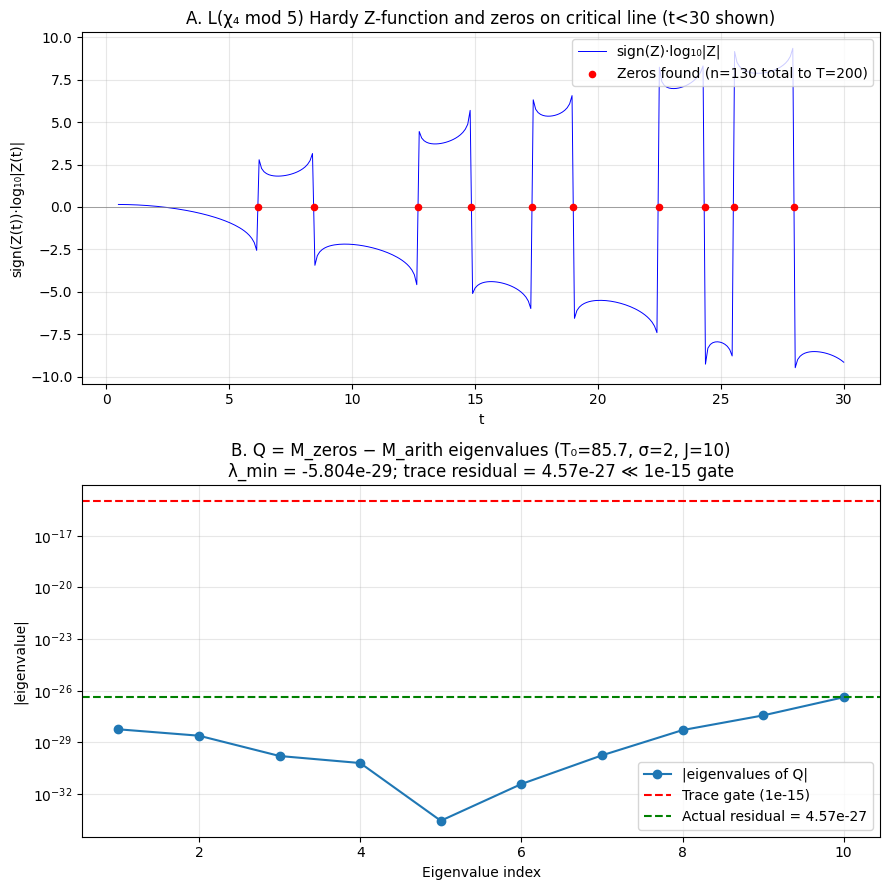

Saved figure


In [44]:
# Make a final summary figure
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(9, 9))

# Panel A: Zeros of L(chi_4 mod 5) on critical line + Hardy Z-function with zero markers
ax = axes[0]
ts_plot = np.linspace(0.5, 200, 1000)
# Re-evaluate Z at coarser grid for plot - use cached approximation
# We have 130 positive zeros; just plot them as ticks plus the Z function
ts_coarse = np.linspace(0.5, 30, 300)
Z_vals = [float(Z_real(mp.mpf(t)).real) for t in ts_coarse]
# log scale
ax.plot(ts_coarse, np.sign(Z_vals)*np.log10(np.abs(Z_vals)+1e-300), 'b-', lw=0.7, label='sign(Z)·log₁₀|Z|')
zeros_to_show = [float(z) for z in zeros_chi_mp if z < 30]
ax.scatter(zeros_to_show, [0]*len(zeros_to_show), color='red', s=20, zorder=5, label=f'Zeros found (n={len(zeros_chi_mp)} total to T=200)')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('t')
ax.set_ylabel('sign(Z(t))·log₁₀|Z(t)|')
ax.set_title('A. L(χ₄ mod 5) Hardy Z-function and zeros on critical line (t<30 shown)')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

# Panel B: trace residual + Q eigenvalues
ax = axes[1]
positions = list(range(1, J+1))
ax.semilogy(positions, np.abs(eigs), 'o-', label='|eigenvalues of Q|')
ax.axhline(1e-15, color='red', ls='--', label='Trace gate (1e-15)')
ax.axhline(float(residual_mat), color='green', ls='--', label=f'Actual residual = {float(residual_mat):.2e}')
ax.set_xlabel('Eigenvalue index')
ax.set_ylabel('|eigenvalue|')
ax.set_title(f'B. Q = M_zeros − M_arith eigenvalues (T₀=85.7, σ=2, J=10)\nλ_min = {eigs[0]:.3e}; trace residual = {float(residual_mat):.2e} ≪ 1e-15 gate')
ax.legend(loc='lower right')
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('Lchi5_trace_validation.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved figure")